# Package 2 (Part 2) – Cross-Validation, Feature Importance, Model Stability

Continues directly from `customer_lifetime_regression.py` (Package 2, part 1): the dataset is not reloaded or re-cleaned, and the three regressors are not retrained from scratch — both the prepared train/test split and the already-fitted models are imported from that script as-is (running the import re-executes its cells once, which is how the fitted `models` dict and the split become available here). This notebook adds 5-fold cross-validation, a model comparison, and per-model feature importance, plus a model-stability discussion. No hyperparameter tuning, SHAP, or business interpretation here.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import KFold, cross_validate

from customer_lifetime_regression import (  # noqa: F401 (build_models/evaluate_model kept for reference)
    X_test,
    X_train,
    build_models,
    evaluate_model,
    models,
    y_test,
    y_train,
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 0
N_SPLITS = 5

Shape: (3490, 19)
Columns: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'ltv_months', 'purchased', 'upsell', 'cumulative_profit', 'referred']
Number of features: 15
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'purchased']
X_train shape: (2792, 15)
X_test shape:  (698, 15)
y_train shape: (2792,)
y_test shape:  (698,)
Trained XGBoost


Trained LightGBM


Trained CatBoost
Best-performing model (lowest RMSE): CatBoost


## 5-Fold Cross-Validation

Run on `X_train`/`y_train` only — `X_test` was already used as the holdout set in Part 1 and stays untouched here, so it remains a valid final check uncontaminated by model-selection decisions made during cross-validation.

In [2]:
def cross_validate_models(models: dict, X: pd.DataFrame, y: pd.Series, cv) -> pd.DataFrame:
    """Run k-fold CV for each model; return Mean/Std RMSE and R², sorted by Mean RMSE.

    `cross_validate` clones and refits each estimator per fold internally, so
    passing the already-fitted `models` dict is safe — it doesn't mutate them.
    """
    rows = []
    for name, model in models.items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        )
        rows.append(
            {
                "Model": name,
                "Mean RMSE": -scores["test_rmse"].mean(),
                "Std RMSE": scores["test_rmse"].std(),
                "Mean R2": scores["test_r2"].mean(),
                "Std R2": scores["test_r2"].std(),
            }
        )
    return pd.DataFrame(rows).sort_values("Mean RMSE").reset_index(drop=True)

In [3]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_comparison = cross_validate_models(models, X_train, y_train, cv)
cv_comparison

,Model,Mean RMSE,Std RMSE,Mean R2,Std R2
0,CatBoost,2.953134,0.208155,0.942994,0.009030
1,LightGBM,2.988797,0.200453,0.941644,0.008783
2,XGBoost,3.237890,0.167080,0.931687,0.007718


In [4]:
best_cv_model_name = cv_comparison.iloc[0]["Model"]
print(f"Best model by 5-fold CV (lowest Mean RMSE): {best_cv_model_name}")

Best model by 5-fold CV (lowest Mean RMSE): CatBoost


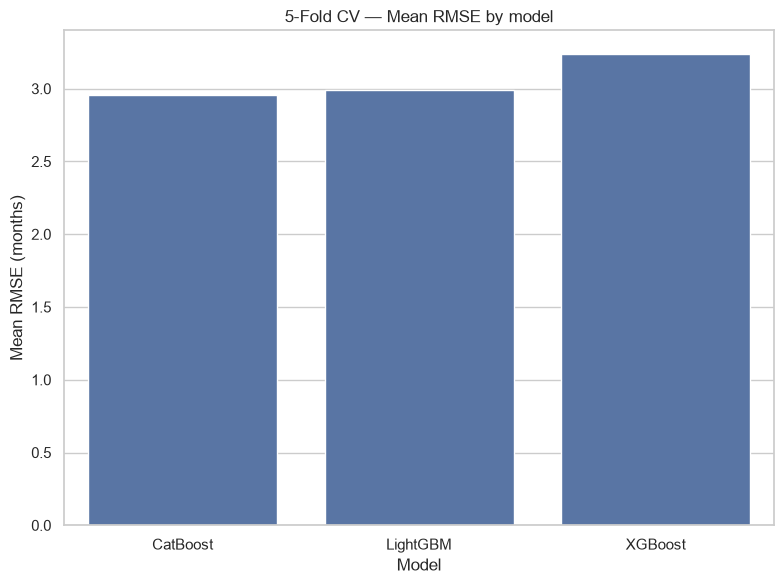

In [5]:
def plot_cv_metric(cv_results: pd.DataFrame, metric: str, ylabel: str, title: str) -> None:
    """Bar chart comparing one CV metric across models, sorted best-first."""
    ordered = cv_results.sort_values(metric, ascending=(metric == "Mean RMSE"))
    plt.figure(figsize=(8, 6))
    sns.barplot(data=ordered, x="Model", y=metric)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_cv_metric(cv_comparison, "Mean RMSE", "Mean RMSE (months)", "5-Fold CV — Mean RMSE by model")

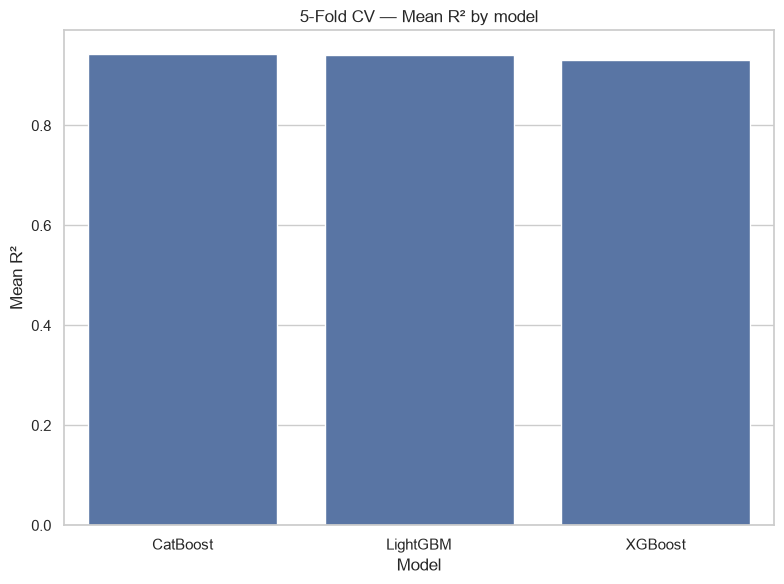

In [6]:
plot_cv_metric(cv_comparison, "Mean R2", "Mean R²", "5-Fold CV — Mean R² by model")

## Feature Importance

Extracted from the already-fitted models (trained in Part 1 on `X_train`). Note: XGBoost's default `.feature_importances_` is gain-based, while LightGBM's default is split-count-based, and CatBoost's `get_feature_importance()` uses PredictionValuesChange (also gain-like) — the three numbers are on different scales and aren't a perfectly apples-to-apples comparison, but their *rankings* are still informative and comparable.

In [7]:
def get_feature_importance(model, feature_names: list[str]) -> pd.Series:
    """Return a Series of feature importances indexed by feature name, descending."""
    if hasattr(model, "get_feature_importance"):  # CatBoost
        importances = model.get_feature_importance()
    else:  # XGBoost / LightGBM
        importances = model.feature_importances_
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)


def plot_feature_importance(importances: pd.Series, model_name: str, top_n: int = 10) -> pd.Series:
    """Horizontal bar chart of the top-N importances (largest at top); returns that slice."""
    top = importances.head(top_n).iloc[::-1]  # reversed so the largest bar ends up on top
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top.to_numpy(), y=top.index, orient="h")
    plt.title(f"Top {top_n} feature importances — {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    return importances.head(top_n)

In [8]:
feature_names = X_train.columns.tolist()
importances_by_model = {
    name: get_feature_importance(model, feature_names) for name, model in models.items()
}

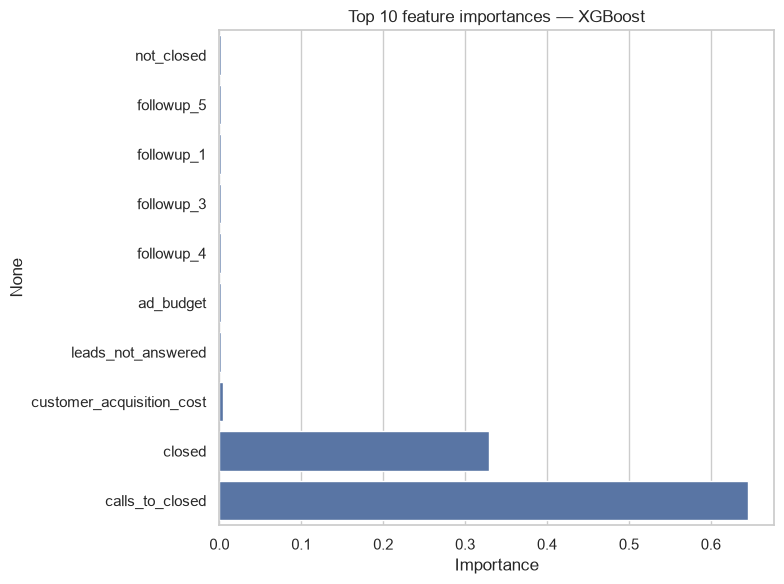

calls_to_closed              0.644907
closed                       0.329386
customer_acquisition_cost    0.004215
leads_not_answered           0.002339
ad_budget                    0.002260
followup_4                   0.002141
followup_3                   0.001992
followup_1                   0.001909
followup_5                   0.001747
not_closed                   0.001708
dtype: float32

In [9]:
top_10_xgboost = plot_feature_importance(importances_by_model["XGBoost"], "XGBoost")
top_10_xgboost

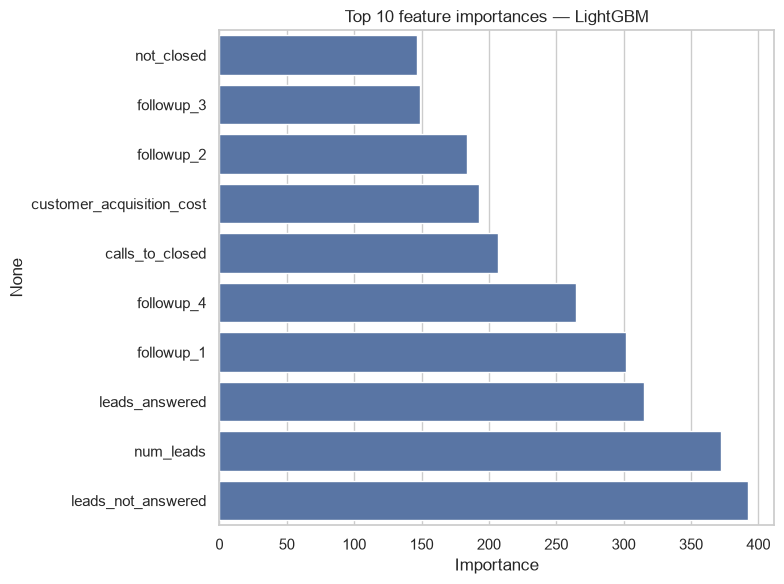

leads_not_answered           392
num_leads                    372
leads_answered               315
followup_1                   302
followup_4                   265
calls_to_closed              207
customer_acquisition_cost    193
followup_2                   184
followup_3                   149
not_closed                   147
dtype: int32

In [10]:
top_10_lightgbm = plot_feature_importance(importances_by_model["LightGBM"], "LightGBM")
top_10_lightgbm

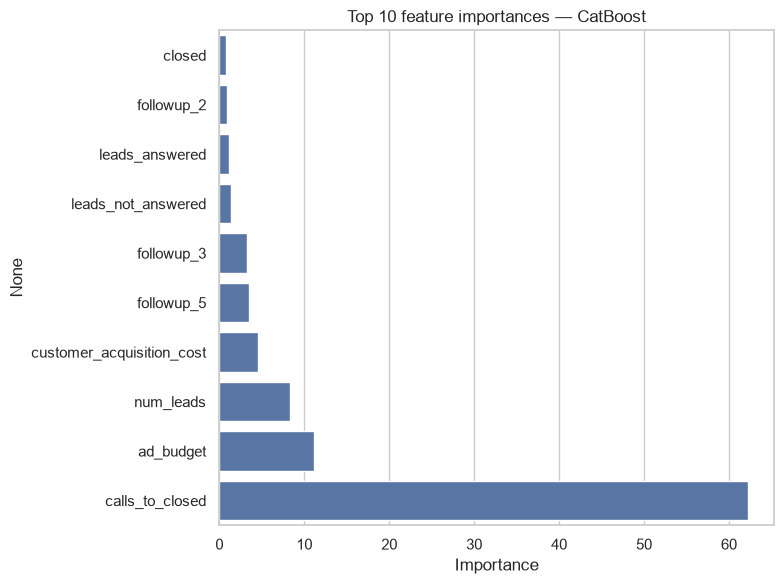

calls_to_closed              62.188305
ad_budget                    11.090919
num_leads                     8.324287
customer_acquisition_cost     4.576451
followup_5                    3.540751
followup_3                    3.238772
leads_not_answered            1.411621
leads_answered                1.097668
followup_2                    0.910029
closed                        0.772048
dtype: float64

In [11]:
top_10_catboost = plot_feature_importance(importances_by_model["CatBoost"], "CatBoost")
top_10_catboost

In [12]:
importance_comparison = pd.DataFrame(
    {
        "XGBoost Importance": importances_by_model["XGBoost"],
        "LightGBM Importance": importances_by_model["LightGBM"],
        "CatBoost Importance": importances_by_model["CatBoost"],
    }
).rename_axis("Feature")
importance_comparison

,XGBoost Importance,LightGBM Importance,CatBoost Importance
Feature,,,
ad_budget,0.002260,111,11.090919
calls_to_closed,0.644907,207,62.188305
calls_to_not_closed,0.001589,143,0.555464
closed,0.329386,72,0.772048
customer_acquisition_cost,0.004215,193,4.576451
followup_1,0.001909,302,0.573743
followup_2,0.001600,184,0.910029
followup_3,0.001992,149,3.238772
followup_4,0.002141,265,0.678070


**Which variables appear consistently important?** Compare each model's top-10 list above (`top_10_xgboost`, `top_10_lightgbm`, `top_10_catboost`) and the full `importance_comparison` table — features that rank highly across all three columns (not just one) are the reliable, model-agnostic signals for `ltv_months`.

**Which variables differ between the models?** A feature ranked highly by one model but low/absent from another's top-10 suggests that model is picking up on a pattern the others aren't weighting as heavily — worth a closer look before trusting it as a business driver rather than an artifact of one algorithm's splitting behavior.

## Model Stability

Judged from the `cv_comparison` table above: a small `Std RMSE`/`Std R2` relative to their respective means means performance barely changes from fold to fold — the model isn't overly sensitive to which rows it happens to train/validate on. It's also worth comparing each model's CV `Mean RMSE`/`Mean R2` against its Part-1 holdout RMSE/R² (from `evaluate_model`/`comparison` in `customer_lifetime_regression.py`, imported above): if the CV mean and the holdout score are close, that's further evidence of good generalization; a CV mean noticeably worse than the holdout score (or a large fold-to-fold spread) would be the signature of overfitting to the particular train/test split used in Part 1.